<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/TareaRegresionLogica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Juan Alejandro Sierra - U00178520

1. ¿Como se pueden optimizar los parametros?
2. ¿Ademas de la funcion sigmoide, existen otras funciones para evaluar la funcion logistica?
3. ¿Que son la funcion perdida y la funcion costo y como se emplea en la regresion logistica?
4. Uso de la curva ROC en regresion logistica
5. Aplicarlo en el dataset diabetes, TITANIC y articulos defectuosos/no defectuosos
6. Elabore un modelo que permita predecir la probabilidad de sufrir cancer cervical usando el siguiente dataset: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

##¿Como se pueden optimizar los parametros?

1. Estimación por máxima verosimilitud (MLE) — la forma estándar: encontrar parámetros que maximizan la probabilidad de los datos. Osea encontrar vecinos que compartan caracteristicas similares

2. Optimizadores basados en librerías: liblinear, lbfgs, saga (scikit-learn) — implementaciones robustas y con regularización.

3. Regularización (evita overfitting): L2 (ridge), L1 (lasso — induce sparsity), ElasticNet. Controlada por hiperparámetro C (en sklearn C = 1/λ).

4. Búsqueda de hiperparámetros: GridSearchCV, RandomizedSearchCV, o búsqueda bayesiana (Optuna, scikit-optimize) para elegir C, tipo de penalización, solver, etc.

5. Escalado de features: crucial para convergencia (StandardScaler, MinMaxScaler).

##¿Además de la función sigmoide, existen otras funciones para evaluar la función logística?

Si, existe la Probit, la Complementary log-log, la Cauchit y Softmax.

##¿Que son la funcion perdida y la funcion costo y como se emplea en la regresion logistica?

Funcion de perdida: Mide la desviación o el margen de error entre la predicción del modelo ($\hat{y}$) y el valor real o valor objetivo ($y$) para una única instancia (un solo punto de dato) del conjunto de entrenamiento.

Funcion costo: Mide el rendimiento promedio del modelo en todo el conjunto de datos de entrenamiento (o en un lote de datos)y busca minimizar durante el entrenamiento para encontrar los parámetros (pesos y sesgos) óptimos del modelo.

##Uso de la curva ROC en regresion logistica

La curva es un gráfico bidimensional donde cada eje representa una tasa de error o acierto del modelo esencial para evaluar el rendimiento de un modelo de clasificación binaria, como la Regresión Logística, en todos sus posibles umbrales de clasificación.

##Ejemplo de uso en la base de datos cdervical cancer risk factors


Clases en objeto retornado: ['clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'pop', 'popitem', 'setdefault', 'update', 'values']
data_obj.data.targets es None — buscando columnas objetivo dentro de features...
Se encontró columna objetivo conocida: 'Biopsy' y se la separó como y
Proporciones de la clase objetivo:
 Biopsy
0    0.935897
1    0.064103
Name: proportion, dtype: float64
NAs por columna (features):
 STDs: Time since last diagnosis     787
STDs: Time since first diagnosis    787
IUD                                 117
IUD (years)                         117
Hormonal Contraceptives             108
Hormonal Contraceptives (years)     108
STDs:HPV                            105
STDs:HIV                            105
STDs:Hepatitis B                    105
STDs:cervical condylomatosis        105
dtype: int64
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/tmp/ipython-input-3930239171.py:30: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X[c] = pd.to_numeric(X[c], errors='ignore')


Mejor params: {'clf__C': 0.1, 'clf__l1_ratio': 0.25}
Mejor AUC CV: 0.9523114502583979
AUC test: 0.9762845849802372
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       161
           1       0.67      0.55      0.60        11

    accuracy                           0.95       172
   macro avg       0.82      0.76      0.79       172
weighted avg       0.95      0.95      0.95       172

Confusion matrix:
 [[158   3]
 [  5   6]]


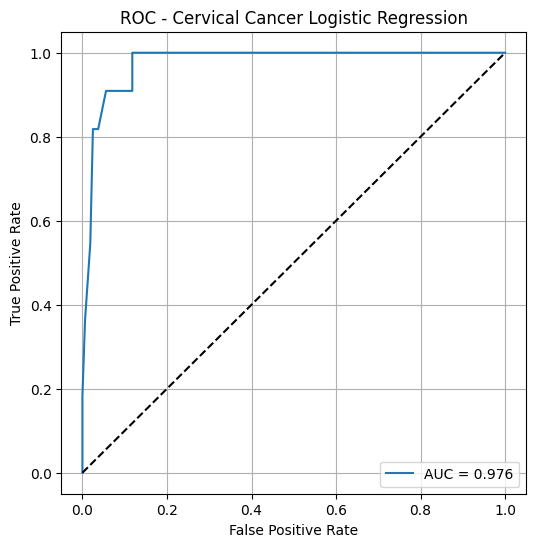

In [5]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

#cargar dataset
data_obj = fetch_ucirepo(id=383)

#inspeccionar dato para evitar None
print("Clases en objeto retornado:", [k for k in dir(data_obj) if not k.startswith('_')][:50])
#acceder a features
X = data_obj.data.features.copy() if getattr(data_obj.data, "features", None) is not None else None
targets_obj = getattr(data_obj.data, "targets", None)

#preprocesar texto de missing y convertir a numéricas
if X is None:
    raise RuntimeError("No pude encontrar 'features' en el objeto retornado por fetch_ucirepo(id=383).")
#reemplazar '?' por NaN y convertir columnas que puedan ser numéricas
X = X.replace('?', np.nan)
for c in X.columns:
    # intentar convertir a numeric (si falla, dejar como está)
    X[c] = pd.to_numeric(X[c], errors='ignore')

#btener y
if targets_obj is not None:
    # si targets existe y no es None, usarlo
    try:
        y = targets_obj.copy().squeeze()
        print("Usando data_obj.data.targets como y")
    except Exception as e:
        print("targets existe pero ocurrió error al copiar:", e)
        y = None
else:
    y = None

#si y es None -> buscar columnas objetivo dentro de X
if y is None:
    print("data_obj.data.targets es None — buscando columnas objetivo dentro de features...")
    # columnas conocidas en este dataset (comunes)
    posible_nombres = ['Biopsy', 'Hinselmann', 'Schiller', 'Cytology', 'diagnosis', 'target']
    found = [name for name in posible_nombres if name in X.columns]
    if found:
        chosen = found[0]
        y = X[chosen].copy()
        X = X.drop(columns=[chosen])
        print(f"Se encontró columna objetivo conocida: '{chosen}' y se la separó como y")
    else:
        # detectar columnas binarias con pocos valores únicos
        bin_cols = []
        for col in X.columns:
            vals = X[col].dropna().unique()
            # convertir float-like 0/1 a ints comparables
            if set(np.unique(vals)).issubset({0,1}) or all([(v in (0,1) or v==0.0 or v==1.0) for v in vals if not pd.isna(v)]):
                bin_cols.append(col)
        if len(bin_cols) > 0:
            chosen = bin_cols[0]
            y = X[chosen].copy()
            X = X.drop(columns=[chosen])
            print(f"No hubo columnas con nombre conocido. Tomé la primera columna binaria detectada: '{chosen}'")
        else:
            # como último recurso, intentar usar data_obj.data.frame o data_obj.data (ver atributos)
            alt = None
            if hasattr(data_obj.data, "frame") and getattr(data_obj.data, "frame") is not None:
                alt = data_obj.data.frame
            elif hasattr(data_obj, "frame") and getattr(data_obj, "frame") is not None:
                alt = data_obj.frame
            if alt is not None:
                # intentar inferir target en alt (buscamos columnas binarias)
                df_alt = alt.copy()
                df_alt = df_alt.replace('?', np.nan)
                for c in df_alt.columns:
                    df_alt[c] = pd.to_numeric(df_alt[c], errors='ignore')
                bin_cols_alt = [c for c in df_alt.columns if set(df_alt[c].dropna().unique()).issubset({0,1})]
                if bin_cols_alt:
                    chosen = bin_cols_alt[0]
                    y = df_alt[chosen].copy()
                    # intentar eliminar la columna de X si coincide por nombre
                    if chosen in X.columns:
                        X = X.drop(columns=[chosen])
                    print(f"Encontrada columna binaria objetivo en un dataframe alternativo: '{chosen}'")
                else:
                    raise RuntimeError("No pude detectar automáticamente una columna objetivo binaria en el dataset. Revisa X.columns y dime cuál usar.")
            else:
                raise RuntimeError("No pude detectar automáticamente una columna objetivo. Revisa X.columns y dime cuál usar.")

#asegurar que y sea númerico y sin strings
y = pd.to_numeric(y, errors='coerce')
print("Proporciones de la clase objetivo:\n", y.value_counts(dropna=False, normalize=True))

#mostrar recuento y decidir imputación más adelante
print("NAs por columna (features):\n", X.isna().sum().sort_values(ascending=False).head(10))

#selección columnas numéricas para pipeline
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise RuntimeError("No hay columnas numéricas detectadas en X. Revisa los tipos de las columnas.")

#datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X[num_cols], y, stratify=y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='saga', max_iter=5000, penalty='elasticnet', l1_ratio=0.5))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Mejor params:", gs.best_params_)
print("Mejor AUC CV:", gs.best_score_)

best = gs.best_estimator_
y_proba = best.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_proba)
print("AUC test:", auc_test)
print(classification_report(y_test, best.predict(X_test)))
print("Confusion matrix:\n", confusion_matrix(y_test, best.predict(X_test)))

#curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_test:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Cervical Cancer Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()
